# Lab 4b: Evaluating an Image Segmentation Model — SOLUTION

Solution notebook for Part 2 of 3 (see `Lab4b_ImageSegmentation.ipynb` for the student
template). As requested, evaluation uses `torchmetrics` throughout — it already did in the
template, since no clean scikit-learn equivalent for image segmentation IoU/Dice exists.


In [2]:
# Setup
!pip install -q torchmetrics


In [3]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

from torchmetrics.segmentation import DiceScore
from torchmetrics.classification import BinaryJaccardIndex
from torchmetrics.functional.segmentation import dice_score as dice_score_fn

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

torch.manual_seed(0)


Using device: cuda


## Task 1: The dataset

In [4]:
subset_size = 200

test_dataset = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types=["segmentation", "binary-category"],
    download=True,
)

rng = np.random.default_rng(0)
subset_indices = rng.choice(len(test_dataset), size=subset_size, replace=False)
print(f"Using {subset_size} of {len(test_dataset)} test images.")
print("Species classes:", test_dataset.bin_classes)


Using 200 of 3669 test images.
Species classes: ['Cat', 'Dog']


Unique trimap values in this image: [1 2 3]


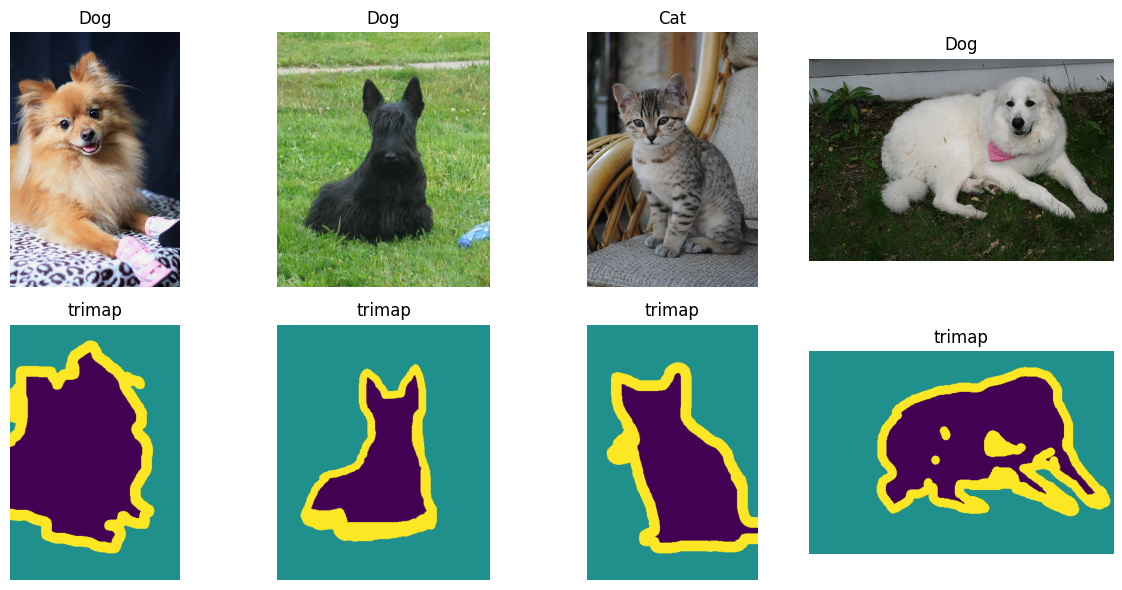

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for col, idx in enumerate(subset_indices[:4]):
    image, (trimap, species) = test_dataset[idx]
    trimap = np.array(trimap)

    axes[0, col].imshow(image)
    axes[0, col].set_title(test_dataset.bin_classes[species])
    axes[0, col].axis("off")

    axes[1, col].imshow(trimap, cmap="viridis", vmin=1, vmax=3)
    axes[1, col].set_title("trimap")
    axes[1, col].axis("off")

print("Unique trimap values in this image:", np.unique(trimap))
plt.tight_layout()
plt.show()


## Task 2: Load a pretrained segmentation model

In [7]:
CAT_IDX, DOG_IDX = 8, 12

weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)
model.eval().to(device)

preprocess = weights.transforms()
print(preprocess)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 171MB/s]  


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Task 3: From model output to a comparable mask

In [8]:
@torch.no_grad()
def predict_mask(image_pil, species_idx):
    '''Returns a (H, W) boolean predicted foreground mask for one PIL image.'''
    input_tensor = preprocess(image_pil).unsqueeze(0).to(device)
    output = model(input_tensor)["out"]  # shape (1, 21, h, w) -- h, w may differ from the original image!

    # Resize back to the original image resolution before thresholding.
    output = F.interpolate(output, size=(image_pil.height, image_pil.width), mode="bilinear", align_corners=False)
    probs = torch.softmax(output, dim=1)
    species_prob = probs[0, species_idx]  # (H, W) probability that each pixel belongs to this image's species

    predicted_mask = species_prob > 0.5
    return predicted_mask.cpu().numpy()


def trimap_to_mask(trimap):
    '''Converts a raw trimap (values 1/2/3) into a binary foreground mask.'''
    trimap = np.array(trimap)
    return (trimap == 1) | (trimap == 3)  # pet (1) or border (3) -> foreground; background (2) stays False


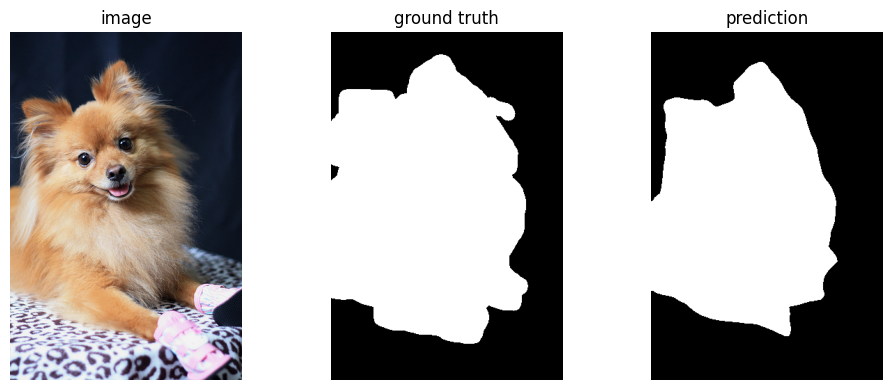

In [9]:
# Quick visual sanity check on one example before running the full evaluation loop.
image, (trimap, species) = test_dataset[subset_indices[0]]

species_idx = CAT_IDX if species == 0 else DOG_IDX
pred_mask = predict_mask(image, species_idx)
gt_mask = trimap_to_mask(trimap)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(image); axes[0].set_title("image"); axes[0].axis("off")
axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("ground truth"); axes[1].axis("off")
axes[2].imshow(pred_mask, cmap="gray"); axes[2].set_title("prediction"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## Task 4: Metrics — IoU and Dice score

In [10]:
iou_metric = BinaryJaccardIndex()
dice_metric = DiceScore(num_classes=2, average="none", input_format="index")  # index 0: background, index 1: foreground

per_image_dice = []

for idx in subset_indices:
    image, (trimap, species) = test_dataset[idx]
    species_idx = CAT_IDX if species == 0 else DOG_IDX

    pred_mask = predict_mask(image, species_idx)
    gt_mask = trimap_to_mask(trimap)

    pred_tensor = torch.from_numpy(pred_mask.astype(int)).unsqueeze(0)
    gt_tensor = torch.from_numpy(gt_mask.astype(int)).unsqueeze(0)

    iou_metric.update(pred_tensor, gt_tensor)
    dice_metric.update(pred_tensor, gt_tensor)
    per_image_dice.append(dice_score_fn(pred_tensor, gt_tensor, num_classes=2, average="none", input_format="index")[0, 1].item())

print(f"Mean IoU (foreground):  {iou_metric.compute().item():.4f}")
print(f"Mean Dice (foreground): {dice_metric.compute()[1].item():.4f}")


Mean IoU (foreground):  0.8357
Mean Dice (foreground): 0.8941


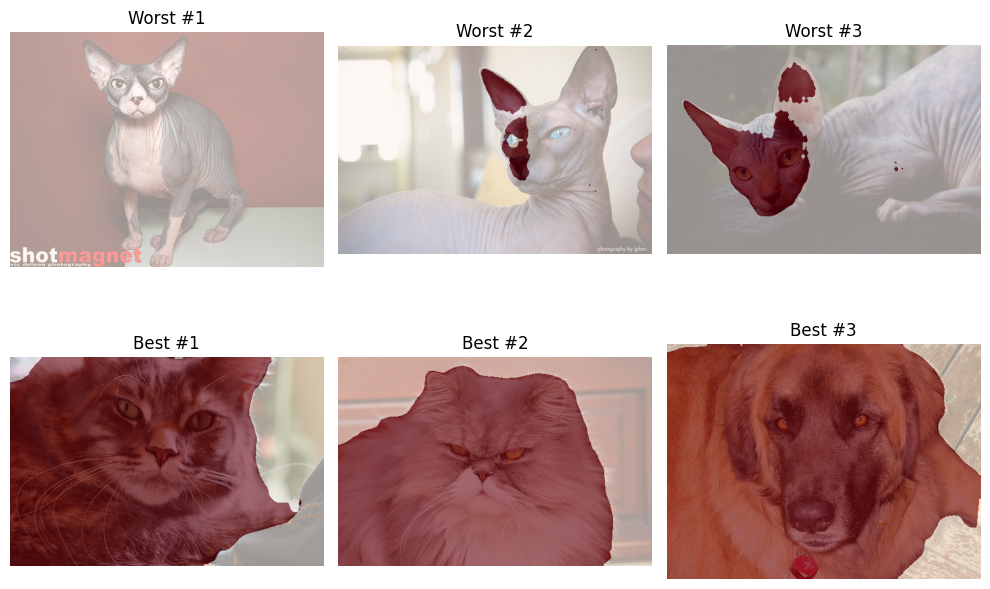

In [13]:
order = np.argsort(per_image_dice)
worst_idx = [subset_indices[i] for i in order[:3]]
best_idx = [subset_indices[i] for i in order[-3:]]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for row, (title, indices) in enumerate([("Worst", worst_idx), ("Best", best_idx)]):
    for col, idx in enumerate(indices):
        image, (trimap, species) = test_dataset[idx]
        species_idx = CAT_IDX if species == 0 else DOG_IDX
        pred_mask = predict_mask(image, species_idx)

        axes[row, col].imshow(image)
        axes[row, col].imshow(pred_mask, cmap="Reds", alpha=0.6)
        axes[row, col].set_title(f"{title} #{col+1}")
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


**Discussion (worked answers):**

- IoU and Dice are indeed highly correlated in these results, exactly as the closed-form
  relationship $\text{Dice} = \frac{2 \cdot \text{IoU}}{1 + \text{IoU}}$ predicts — Dice is
  always somewhat higher than IoU for the same mask pair, but they move together and rank
  images the same way.
- The worst-scoring images typically involve one or more of: the pet only partially in
  frame, unusual poses/heavy occlusion, or a cluttered/textured background that shares
  color statistics with the animal's fur.
- Fine-tuning would very likely help, since the model was trained on VOC/COCO-style
  photos and has never seen the specific breed/pose/background distribution of
  Oxford-IIIT Pet; even a few epochs of fine-tuning the decoder head typically closes much
  of this domain gap.
- Mask R-CNN gives per-*instance* masks with an associated class and confidence score,
  rather than one dense per-pixel class map. Evaluating it would mean first matching
  predicted instances to ground truth (e.g. via mask IoU, similar to Lab 4c's box
  matching) before computing Dice/IoU per matched pair, rather than directly thresholding
  a single per-class probability channel as we did here.

---

**Next up:** `Lab4c_ObjectDetection_Solution.ipynb`.